# Nova Pay Fraud Detection - Data Cleaning & Preparation Pipeline

## Comprehensive step-by-step data cleaning with exploration and fixing

This notebook demonstrates all critical data cleaning steps in logical order:
1. **Install & Import Libraries** - Setup all dependencies
2. **Load & Assess Data** - Initial exploration and baseline metrics
3. **Remove Duplicates** - Identify and remove exact duplicates
4. **Fix Data Types** - Convert columns to appropriate types (including amount_src, timestamp)
5. **Standardize Text** - Fix inconsistencies in categorical columns
6. **Handle Data Inconsistencies & Outliers** - Fix negative values, cap extremes, fix invalid ranges
7. **Handle Missing Values** - Explore, compare methods (KNN vs Median), apply best approach
8. **Separate Identifier Columns** - Subset IDs into their own DataFrame (NEW — see teaching note)
9. **Feature Engineering** - Use identifiers to build behaviour features (customer totals, device counts), then validate
10. **Class Imbalance Analysis** - Document fraud distribution
11. **Final Validation** - Comprehensive data quality report
12. **Save Cleaned Dataset** - Export features and identifiers separately

## STEP 1: INSTALL & IMPORT LIBRARIES

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

print('All libraries installed and imported successfully')

All libraries installed and imported successfully


## STEP 2: LOAD & ASSESS DATA

In [2]:
data = pd.read_csv('../data/nova_pay_combined.csv')

print('=' * 80)
print('ORIGINAL DATASET LOADED')
print('=' * 80)
print(f'Shape: {data.shape}')
print(f'\nColumns: {list(data.columns)}')
print(f'\nData Types:\n{data.dtypes}')
print(f'\nMemory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

ORIGINAL DATASET LOADED
Shape: (11400, 26)

Columns: ['transaction_id', 'customer_id', 'timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id', 'new_device', 'ip_address', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud']

Data Types:
transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                       str
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address   

### 📚 TEACHING NOTE — What is an *identifier* column, and why does it need special care?

Before we clean anything, we need to understand the **two fundamentally different kinds of columns** in this dataset.

**1. Descriptive columns (features).** These describe a *property* of a transaction that could be true of many transactions — `channel = "mobile"`, `amount_usd = 250.00`, `kyc_tier = "standard"`. A model can learn from these because the same value appears across many rows and carries shared meaning.

**2. Identifier columns (IDs).** These exist only to *label one specific thing* — `transaction_id` names one transaction, `customer_id` names one person, `device_id` names one phone or laptop, `ip_address` names one network origin. The value itself carries no general pattern; it is just a tag.

**The test you can always apply:** *Does this value mean something that generalises across rows, or is it just a unique name?* Count the unique values — if a column has almost as many unique values as there are rows, it is an identifier.

**Why identifiers need to be handled separately — three concrete reasons:**

1. **They explode one-hot encoding.** Later we convert text columns into numeric 0/1 columns (one new column per unique value). A column with 25,000 unique customer IDs becomes 25,000 columns — this is exactly the "why do I have 25,000 columns?" problem. Descriptive columns like `channel` only have a handful of unique values, so they stay small.
2. **They cause data leakage and overfitting.** If the model can see a raw `customer_id`, it can *memorise* "customer #4471 was fraud last time" instead of *learning the patterns* that make fraud detectable. It would look brilliant on training data and fail on every new customer it has never seen.
3. **They do not generalise.** Every future transaction arrives with a brand-new `transaction_id` the model has never encountered, so any rule keyed to specific IDs can never fire in production.

**But — and this is the key insight — identifiers are still extremely useful.** We do not *throw them away*. We use them to **count and group behaviour**: "how many transactions has this customer made?" (`customer_total_transactions`), "how many devices has this customer used?" (`customer_device_count`). These engineered features summarise the identity into something a model *can* learn from, while the raw ID never reaches the model.

**Our strategy:** keep the identifiers in their own separate DataFrame. Exclude them from cleaning steps that only make sense for numbers/categories (like outlier capping and one-hot encoding), but keep them available so feature engineering can group by them. We join everything back together using the row's position, and only the *engineered* behaviour features survive into the model.

In [3]:
# DIAGNOSTIC: measure the cardinality (number of unique values) of every column.
# This is how we DETECT identifiers empirically rather than guessing.
print('CARDINALITY CHECK — unique values per column')
print('=' * 70)
print(f'{"Column":30} {"dtype":12} {"unique":>10} {"% of rows":>12}')
print('-' * 70)
n_rows = len(data)
for col in data.columns:
    nu = data[col].nunique()
    pct = nu / n_rows * 100
    flag = '  <-- IDENTIFIER COLUMN' if pct > 90 else ''
    print(f'{col:30} {str(data[col].dtype):12} {nu:>10,} {pct:>11.1f}%{flag}')

print('\n📌 Rule of thumb: any column whose unique count is close to the number of rows')
print('   (≈100%) is an identifier. Notice transaction_id is unique per row, and')
print('   customer_id / device_id / ip_address repeat, but are still high-cardinality.')

CARDINALITY CHECK — unique values per column
Column                         dtype            unique    % of rows
----------------------------------------------------------------------
transaction_id                 str              11,200        98.2%  <-- IDENTIFIER COLUMN
customer_id                    str               1,315        11.5%
timestamp                      str              11,141        97.7%  <-- IDENTIFIER COLUMN
home_country                   str                   7         0.1%
source_currency                str                   3         0.0%
dest_currency                  str                   9         0.1%
channel                        str                  12         0.1%
amount_src                     str               9,856        86.5%
amount_usd                     float64           9,621        84.4%
fee                            float64           1,676        14.7%
exchange_rate_src_to_dest      float64              25         0.2%
device_id             

In [4]:
baseline_rows = len(data)
baseline_cols = len(data.columns)
baseline_duplicates = data.duplicated().sum()
baseline_missing = data.isnull().sum().sum()

print('\n📊 BASELINE METRICS')
print(f'  Total rows: {baseline_rows:,}')
print(f'  Total columns: {baseline_cols}')
print(f'  Duplicate rows: {baseline_duplicates}')
print(f'  Total missing values: {baseline_missing:,}')
print(f'  Fraud rate: {data["is_fraud"].mean():.2%}')


📊 BASELINE METRICS
  Total rows: 11,400
  Total columns: 26
  Duplicate rows: 200
  Total missing values: 1,830
  Fraud rate: 8.75%


## STEP 3: REMOVE DUPLICATES

### 3.1 EXPLORE: Identify duplicate rows

In [5]:
dup_mask = data.duplicated(keep=False) # Mark all duplicates (including the first occurrence)
dup_count = data.duplicated().sum()

print(f'\n🔍 DUPLICATE ROWS EXPLORATION\n')
print(f'Total exact duplicate rows: {dup_count}')

if dup_count > 0:
    dup_rows = data[dup_mask].sort_values('transaction_id')
    dup_transaction = dup_rows['transaction_id'].iloc[0]                 # Get the transaction_id of the first duplicate set
    print(f'\n📋 Example: Duplicate rows with transaction_id \'{dup_transaction}\':\n')
    print(data[data['transaction_id'] == dup_transaction].to_string())


🔍 DUPLICATE ROWS EXPLORATION

Total exact duplicate rows: 200

📋 Example: Duplicate rows with transaction_id '03368cab-696b-4984-bffb-3429267e57b2':

                             transaction_id                           customer_id                         timestamp home_country source_currency dest_currency channel amount_src  amount_usd  fee  exchange_rate_src_to_dest                             device_id  new_device       ip_address ip_country  location_mismatch  ip_risk_score  kyc_tier  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk  is_fraud
5866   03368cab-696b-4984-bffb-3429267e57b2  7bd5200c-5d19-44f0-9afe-8b339a05366b  2024-06-29 04:15:54.468549+00:00           US             USD           GBP     ATM     299.24      299.24  4.7                        0.8  3104801a-ba96-4c81-9aef-97a6f8838548       False  168.133.242.223         US              False          0.202  standard               14

### 3.2 FIX: Remove duplicate rows

In [6]:
dup_before = len(data)
data = data.drop_duplicates(keep='first')
dup_after = len(data)
print(f'✓ Removed duplicate rows: {dup_before - dup_after}')
print(f'✓ Remaining rows: {dup_after:,}')

✓ Removed duplicate rows: 200
✓ Remaining rows: 11,200


## STEP 4: FIX DATA TYPES

### 4.1 EXPLORE: Check current data types

In [7]:
print('\n🔍 DATA TYPE ISSUES EXPLORATION\n')
print('Current data types:')
print(data.dtypes)

print('\n📋 amount_src column (STORED AS STRING - needs conversion):')
print(f'  Type: {data["amount_src"].dtype}')
print(f'  Sample values: {data["amount_src"].head(10).tolist()}')
print(f'  Unique values: {data["amount_src"].nunique()}')

print('\n📋 timestamp column (needs proper datetime parsing):')
print(f'  Type: {data["timestamp"].dtype}')
print(f'  Sample values:\n{data["timestamp"].head(5)}')


🔍 DATA TYPE ISSUES EXPLORATION

Current data types:
transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                       str
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address                       str
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud              

### 4.2 FIX: Convert to proper data types

In [8]:
data['amount_src'] = pd.to_numeric(data['amount_src'], errors='coerce')
print(f'✓ Converted amount_src to float')
print(f'  Type: {data["amount_src"].dtype}')
print(f'  Sample values: {data["amount_src"].head(5).tolist()}')

data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')
print(f'\n✓ Converted timestamp to datetime')
print(f'  Type: {data["timestamp"].dtype}')
print(f'  Date range: {data["timestamp"].min()} to {data["timestamp"].max()}')

categorical_cols = ['home_country', 'source_currency', 'dest_currency', 'channel', 'kyc_tier']
for col in categorical_cols:
    data[col] = data[col].astype('object')
print(f'\n✓ Ensured categorical columns have object dtype')

print(f'\n📊 Updated data types:')
print(data[['amount_src', 'timestamp', 'channel', 'kyc_tier']].dtypes)

# Select only numeric columns (floats and integers) 
numeric_data = data.select_dtypes(include=[np.number])

# Generate and print the summary statistics
print('NUMERIC SUMMARY STATISTICS')
print('='*40)
print(numeric_data.describe())

✓ Converted amount_src to float
  Type: float64
  Sample values: [278.19, 208.51, 160.33, 59.41, 200.96]

✓ Converted timestamp to datetime
  Type: datetime64[us, UTC]
  Date range: 2022-10-03 18:40:59.468549+00:00 to 2025-12-16 00:13:41.468549+00:00

✓ Ensured categorical columns have object dtype

📊 Updated data types:
amount_src                float64
timestamp     datetime64[us, UTC]
channel                    object
kyc_tier                   object
dtype: object
NUMERIC SUMMARY STATISTICS
         amount_src    amount_usd           fee  exchange_rate_src_to_dest  \
count  11196.000000  10900.000000  10910.000000               11200.000000   
mean     434.913110    451.710904     99.212001                 167.453693   
std     1364.347282   1401.028359    952.526927                 381.930143   
min    -9997.160000      7.230000     -1.000000                   0.592000   
25%       90.692500     92.492500      2.380000                   1.000000   
50%      158.925000    163.48500

## STEP 5: STANDARDIZE TEXT DATA

### 5.1 EXPLORE: Text inconsistencies

In [9]:
print('\n🔍 TEXT INCONSISTENCIES EXPLORATION\n')

print('HOME_COUNTRY - Whitespace and duplicate values:')
print(f'  Unique values: {data["home_country"].unique()}')
print(f'  Value counts:\n{data["home_country"].value_counts(dropna=False)}') 

print('\n\nCHANNEL - Case variations, typos, and whitespace:')
print(f'  Unique values: {data["channel"].unique()}')
print(f'  Value counts:\n{data["channel"].value_counts(dropna=False)}')

print('\n\nKYC_TIER - Case variations, typos, and null representations:')
print(f'  Unique values: {data["kyc_tier"].unique()}')
print(f'  Value counts:\n{data["kyc_tier"].value_counts(dropna=False)}')


🔍 TEXT INCONSISTENCIES EXPLORATION

HOME_COUNTRY - Whitespace and duplicate values:
  Unique values: ['US' 'CA' 'UK' ' UK  ' ' US  ' 'unknown' ' CA  ']
  Value counts:
home_country
US         7784
UK         2091
CA         1205
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64


CHANNEL - Case variations, typos, and whitespace:
  Unique values: ['ATM' 'web' 'mobile' 'WEB' ' web  ' 'MOBILE' 'mobille' 'unknown'
 ' mobile  ' 'weeb' 'ATm' ' ATM  ']
  Value counts:
channel
mobile       6242
web          3674
ATM           989
mobille        59
 mobile        48
MOBILE         46
unknown        37
WEB            35
 web           33
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64


KYC_TIER - Case variations, typos, and null representations:
  Unique values: ['standard' 'enhanced' 'low' ' standard  ' nan 'standrd' ' enhanced  '
 'STANDARD' 'NAN' 'unknown' 'enhancd' ' low  ' 'ENHANCED' 'LOW' ' nan  ']
  Value counts:
ky

### 5.2 FIX: Standardize text

In [10]:
print(f'✓ STANDARDIZING TEXT DATA\n')
data['home_country'] = data['home_country'].str.strip().str.upper()
print(f'  home_country standardized to uppercase and stripped')
print(f'    Unique values now: {data["home_country"].unique()}')

data['channel'] = data['channel'].str.strip().str.lower()
channel_replacements = {'mobille': 'mobile', 'weeb': 'web', 'atm': 'atm'}
for typo, correct in channel_replacements.items():
    data['channel'] = data['channel'].replace(typo, correct)
print(f'  channel standardized and typos fixed')
print(f'    Unique values now: {data["channel"].unique()}')

data['kyc_tier'] = data['kyc_tier'].str.strip().str.lower()
kyc_replacements = {'standrd': 'standard', 'enhancd': 'enhanced', 'nan': np.nan, 'unknown': 'unknown'}
for typo, correct in kyc_replacements.items():
    data['kyc_tier'] = data['kyc_tier'].replace(typo, correct)
print(f'  kyc_tier standardized and typos fixed')
print(f'    Unique values now: {sorted([x for x in data["kyc_tier"].unique() if pd.notna(x)])}')

print(f'\n📊 After text standardization:')
print(f'  home_country unique: {data["home_country"].nunique()}')
print(f'  channel unique: {data["channel"].nunique()}')
print(f'  kyc_tier unique: {data["kyc_tier"].nunique()}')

✓ STANDARDIZING TEXT DATA

  home_country standardized to uppercase and stripped
    Unique values now: ['US' 'CA' 'UK' 'UNKNOWN']
  channel standardized and typos fixed
    Unique values now: ['atm' 'web' 'mobile' 'unknown']
  kyc_tier standardized and typos fixed
    Unique values now: ['enhanced', 'low', 'standard', 'unknown']

📊 After text standardization:
  home_country unique: 4
  channel unique: 4
  kyc_tier unique: 4


## STEP 6: HANDLE DATA INCONSISTENCIES & OUTLIERS

### 6.1 EXPLORE: Identify problematic values

In [11]:
print('\n🔍 DATA INCONSISTENCIES & OUTLIERS EXPLORATION\n')

neg_fee = data[data['fee'] < 0]
print(f'Negative fees: {len(neg_fee)}')
if len(neg_fee) > 0:
    print(f'  Examples: {neg_fee["fee"].head(5).tolist()}')

extreme_fee = data[data['fee'] >= 9999.99]
print(f'\nExtreme fees (>= $9999.99): {len(extreme_fee)}')
if len(extreme_fee) > 0:
    print(f'  Max fee: ${data["fee"].max():.2f}')
    print(f'  Examples: {extreme_fee["fee"].head(5).tolist()}')

neg_device_trust_score = data[data['device_trust_score'] < 0]
print(f'\nNegative device trust scores: {len(neg_device_trust_score)}')
if len(neg_device_trust_score) > 0:
    print(f'  Examples: {neg_device_trust_score["device_trust_score"].head(5).tolist()}')

neg_txn_velocity_1h = data[data['txn_velocity_1h'] < 0]
print(f'\nNegative transaction velocities (1h): {len(neg_txn_velocity_1h)}')
if len(neg_txn_velocity_1h) > 0:
    print(f'  Examples: {neg_txn_velocity_1h["txn_velocity_1h"].head(5).tolist()}')

neg_amount_src = data[data['amount_src'] < 0]
print(f'\nNegative source amounts: {len(neg_amount_src)}')
if len(neg_amount_src) > 0:
    print(f'  Examples: {neg_amount_src["amount_src"].head(5).tolist()}')

invalid_ip_risk_score = data[data['ip_risk_score'] > 1]
print(f'\nInvalid IP risk scores (> 1): {len(invalid_ip_risk_score)}')

invalid_exchange = data[data['exchange_rate_src_to_dest'] <= 0]
print(f'\nInvalid exchange rates (<= 0): {len(invalid_exchange)}')

print(f'\nAmount statistics:')
print(f'  amount_src: Min=${data["amount_src"].min():.2f}, Max=${data["amount_src"].max():.2f}')
print(f'  fee: Min=${data["fee"].min():.2f}, Max=${data["fee"].max():.2f}')
print(f'  device_trust_score: Min={data["device_trust_score"].min():.2f}, Max={data["device_trust_score"].max():.2f}')
print(f'  txn_velocity_1h: Min={data["txn_velocity_1h"].min():.2f}, Max={data["txn_velocity_1h"].max():.2f}')
print(f'  ip_risk_score: Min={data["ip_risk_score"].min():.2f}, Max={data["ip_risk_score"].max():.2f}')
print(f'  amount_usd: Min=${data["amount_usd"].min():.2f}, Max=${data["amount_usd"].max():.2f}')


🔍 DATA INCONSISTENCIES & OUTLIERS EXPLORATION

Negative fees: 100
  Examples: [-1.0, -1.0, -1.0, -1.0, -1.0]

Extreme fees (>= $9999.99): 100
  Max fee: $9999.99
  Examples: [9999.99, 9999.99, 9999.99, 9999.99, 9999.99]

Negative device trust scores: 200
  Examples: [-0.1, -0.1, -0.1, -0.1, -0.1]

Negative transaction velocities (1h): 200
  Examples: [-1, -1, -1, -1, -1]

Negative source amounts: 100
  Examples: [-37.08, -176.92, -702.71, -230.36, -203.83]

Invalid IP risk scores (> 1): 200

Invalid exchange rates (<= 0): 0

Amount statistics:
  amount_src: Min=$-9997.16, Max=$11942.89
  fee: Min=$-1.00, Max=$9999.99
  device_trust_score: Min=-0.10, Max=1.00
  txn_velocity_1h: Min=-1.00, Max=8.00
  ip_risk_score: Min=0.00, Max=1.20
  amount_usd: Min=$7.23, Max=$12498.57


### 6.2 FIX: Correct inconsistencies

In [12]:
# Handle Negative Fees: Set to NaN for KNN prediction
neg_fee_before = (data['fee'] < 0).sum()
data.loc[data['fee'] < 0, 'fee'] = np.nan
print(f'✓ Identified negative fees: {neg_fee_before} rows set to NaN for imputation')

# Handle 9999.99 values in Fee
fee_9999_before = (data['fee'] == 9999.99).sum()
data.loc[data['fee'] == 9999.99, 'fee'] = np.nan
print(f'✓ Identified 9999.99 values: {fee_9999_before} rows set to NaN for imputation')

# Handle negative amount_src
neg_amount_src_before = (data['amount_src'] < 0).sum()
data.loc[data['amount_src'] < 0, 'amount_src'] = np.nan
print(f'✓ Identified negative amount_src: {neg_amount_src_before} rows set to NaN for imputation')

# Handle negative Transaction Velocity values
neg_txn_vel_1h_before = (data['txn_velocity_1h'] < 0).sum()
data.loc[data['txn_velocity_1h'] < 0, 'txn_velocity_1h'] = np.nan
print(f'✓ Identified negative txn_velocity_1h: {neg_txn_vel_1h_before} rows set to NaN for imputation')

# Handle negative device_trust_score values
neg_device_trust_score = (data['device_trust_score'] < 0).sum()
data.loc[data['device_trust_score'] < 0, 'device_trust_score'] = np.nan
print(f'✓ Identified negative device_trust_score: {neg_device_trust_score} rows set to NaN for imputation')

# Handle invalid IP risk scores
invalid_ip_risk_score = (data['ip_risk_score'] > 1).sum()
data.loc[data['ip_risk_score'] > 1, 'ip_risk_score'] = np.nan
print(f'✓ Identified invalid IP risk scores: {invalid_ip_risk_score} rows set to NaN for imputation')

print(f'\n📊 Summary after setting values to NaN:')
print(f'  Total rows: {len(data):,}')
print(f'  Current missing values in fee: {data["fee"].isna().sum()}')
print(f'  Current missing values in amount_usd: {data["amount_usd"].isna().sum()}')
print(f'  Current missing values in amount_src: {data["amount_src"].isna().sum()}')
print(f'  Current missing values in txn_velocity_1h: {data["txn_velocity_1h"].isna().sum()}')
print(f'  Current missing values in device_trust_score: {data["device_trust_score"].isna().sum()}')
print(f'  Current missing values in ip_risk_score: {data["ip_risk_score"].isna().sum()}')

✓ Identified negative fees: 100 rows set to NaN for imputation
✓ Identified 9999.99 values: 100 rows set to NaN for imputation
✓ Identified negative amount_src: 100 rows set to NaN for imputation
✓ Identified negative txn_velocity_1h: 200 rows set to NaN for imputation
✓ Identified negative device_trust_score: 200 rows set to NaN for imputation
✓ Identified invalid IP risk scores: 200 rows set to NaN for imputation

📊 Summary after setting values to NaN:
  Total rows: 11,200
  Current missing values in fee: 490
  Current missing values in amount_usd: 300
  Current missing values in amount_src: 104
  Current missing values in txn_velocity_1h: 200
  Current missing values in device_trust_score: 490
  Current missing values in ip_risk_score: 200


## STEP 7: HANDLE MISSING VALUES

### 7.1 EXPLORE: Missing values overview

In [13]:
print('\n🔍 MISSING VALUES EXPLORATION\n')
missing_summary = data.isnull().sum()
missing_pct = (missing_summary / len(data) * 100).round(2)
missing_data = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing Count': missing_summary.values,
    'Missing %': missing_pct.values
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

print('Columns with missing values:')
print(missing_data.to_string(index=False))

print('\n\n📋 Example rows with MISSING TIMESTAMP:')
print(data[data['timestamp'].isna()][['transaction_id', 'customer_id', 'timestamp', 'amount_usd', 'is_fraud']].head(10))

print('\n📋 Example rows with MISSING KYC_TIER:')
print(data[data['kyc_tier'].isna()][['transaction_id', 'customer_id', 'kyc_tier', 'amount_usd']].head(10))


🔍 MISSING VALUES EXPLORATION

Columns with missing values:
            Column  Missing Count  Missing %
device_trust_score            490       4.38
               fee            490       4.38
        ip_address            300       2.68
        amount_usd            300       2.68
          kyc_tier            298       2.66
        ip_country            296       2.64
     ip_risk_score            200       1.79
   txn_velocity_1h            200       1.79
        amount_src            104       0.93
         timestamp             60       0.54


📋 Example rows with MISSING TIMESTAMP:
                            transaction_id  \
40    d36a0593-5a44-4174-a5ed-cc7317bc8524   
158   e6ef7b85-c19f-43fa-befa-743e37c62583   
160   2b64ca36-f140-4de4-9cc8-c678255402a9   
210   7f3f5c09-b75c-4355-aca4-d70e169d6df6   
578   b371fb34-0744-4b90-b33d-237b95b0cd52   
1003  3e96cacd-3722-469f-95c1-6dce5ba73aa6   
1325  c646535b-dd51-4d09-b155-e603bbafdc7e   
1501  f340c84f-8021-483c-9a7e-b1fae2

### 7.2 KNN IMPUTATION ANALYSIS: Relationship Analysis & Comparison with Median

#### Step 1: Identify relationships for KNN imputation

In [14]:
data_imputation = data.copy()

print('\n🔍 KNN IMPUTATION - RELATIONSHIP ANALYSIS\n')

numerical_cols_with_missing = {
    'fee': data_imputation['fee'].isna().sum(), 
    'amount_usd': data_imputation['amount_usd'].isna().sum(),
    'device_trust_score': data_imputation['device_trust_score'].isna().sum(),
    'amount_src': data_imputation['amount_src'].isna().sum(),
    'txn_velocity_1h': data_imputation['txn_velocity_1h'].isna().sum(),
    'ip_risk_score': data_imputation['ip_risk_score'].isna().sum()
}

print('Numerical columns with missing values:')
for col, count in numerical_cols_with_missing.items():
    print(f'  {col}: {count} missing values')

numeric_data = data_imputation.select_dtypes(include=[np.number]).drop(columns=['is_fraud'], errors='ignore').copy()

print('\n' + '='*80)
print('CORRELATION ANALYSIS - Finding relationships')
print('='*80 + '\n')

relationships = {}

for target_col in numerical_cols_with_missing.keys():
    if target_col not in numeric_data.columns:
        continue
    
    correlations = numeric_data.corr()[target_col].drop(target_col).sort_values(ascending=False)
    top_pos = correlations.head(5)
    top_neg = correlations.tail(5)
    top_related = pd.concat([top_pos, top_neg]).drop_duplicates()
    
    relationships[target_col] = top_related
    
    print(f'\n{target_col.upper()} - Related variables (correlation strength):')
    print('-' * 60)
    for var, corr in top_related.items():
        if pd.notna(corr) and abs(corr) > 0.01:
            print(f'  {var:.<40} {corr:>7.3f}')


🔍 KNN IMPUTATION - RELATIONSHIP ANALYSIS

Numerical columns with missing values:
  fee: 490 missing values
  amount_usd: 300 missing values
  device_trust_score: 490 missing values
  amount_src: 104 missing values
  txn_velocity_1h: 200 missing values
  ip_risk_score: 200 missing values

CORRELATION ANALYSIS - Finding relationships


FEE - Related variables (correlation strength):
------------------------------------------------------------
  amount_src..............................   1.000
  amount_usd..............................   0.990
  txn_velocity_24h........................   0.107
  txn_velocity_1h.........................   0.096
  risk_score_internal.....................   0.087
  chargeback_history_count................   0.078
  exchange_rate_src_to_dest...............   0.027
  corridor_risk...........................   0.025
  account_age_days........................  -0.034
  device_trust_score......................  -0.072

AMOUNT_USD - Related variables (correlation

#### Step 2: Apply KNN Imputation

In [15]:
print('\n' + '='*80)
print('APPLYING KNN IMPUTATION')
print('='*80 + '\n')

numeric_cols = data_imputation.select_dtypes(include=[np.number]).columns.tolist()                  # Get all numeric columns for KNN imputation

original_missing_mask = {}
for col in ['fee', 'amount_usd', 'amount_src', 'txn_velocity_1h', 'ip_risk_score', 'device_trust_score']:
    if col in data_imputation.columns:
        original_missing_mask[col] = data_imputation[col].isna().copy()

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
data_knn = data_imputation.copy()
data_knn[numeric_cols] = knn_imputer.fit_transform(data_imputation[numeric_cols])

print('✓ KNN Imputation completed with k=5 neighbors')
print(f'  Using weighted distance (closer neighbors have higher influence)\n')

print('KNN IMPUTATION RESULTS:')
print('-' * 80)

for col in ['fee', 'amount_usd', 'amount_src', 'txn_velocity_1h', 'ip_risk_score', 'device_trust_score']:
    if col in original_missing_mask:
        missing_count = original_missing_mask[col].sum()
        if missing_count > 0:
            imputed_values = data_knn.loc[original_missing_mask[col], col]
            print(f'\n{col.upper()}:')
            print(f'  Missing values imputed: {missing_count}')
            print(f'  Mean of imputed values: ${imputed_values.mean():.2f}' if col in ['fee', 'amount_usd'] else f'  Mean of imputed values: {imputed_values.mean():.4f}')
            print(f'  Std of imputed values:  ${imputed_values.std():.2f}' if col in ['fee', 'amount_usd'] else f'  Std of imputed values:  {imputed_values.std():.4f}')
            print(f'  Min/Max: ${imputed_values.min():.2f} - ${imputed_values.max():.2f}' if col in ['fee', 'amount_usd'] else f'  Min/Max: {imputed_values.min():.4f} - {imputed_values.max():.4f}')
            print(f'  Example imputed values: {imputed_values.head(3).round(2).tolist()}')


APPLYING KNN IMPUTATION

✓ KNN Imputation completed with k=5 neighbors
  Using weighted distance (closer neighbors have higher influence)

KNN IMPUTATION RESULTS:
--------------------------------------------------------------------------------

FEE:
  Missing values imputed: 490
  Mean of imputed values: $6.46
  Std of imputed values:  $17.69
  Min/Max: $0.71 - $151.22
  Example imputed values: [5.39, 4.63, 1.59]

AMOUNT_USD:
  Missing values imputed: 300
  Mean of imputed values: $430.65
  Std of imputed values:  $1084.27
  Min/Max: $24.69 - $9995.95
  Example imputed values: [451.62, 502.24, 402.27]

AMOUNT_SRC:
  Missing values imputed: 104
  Mean of imputed values: 386.6358
  Std of imputed values:  652.0756
  Min/Max: 20.3900 - 3979.8233
  Example imputed values: [174.04, 450.71, 201.07]

TXN_VELOCITY_1H:
  Missing values imputed: 200
  Mean of imputed values: 0.0750
  Std of imputed values:  0.3995
  Min/Max: 0.0000 - 4.3505
  Example imputed values: [0.0, 0.0, 0.0]

IP_RISK_SCO

#### Step 3: Compare KNN vs Median Imputation

In [16]:
print('\n' + '='*80)
print('MEDIAN IMPUTATION (for comparison)')
print('='*80 + '\n')

data_median = data_imputation.copy()

median_stats = {}
for col in ['fee', 'amount_usd', 'amount_src', 'txn_velocity_1h', 'ip_risk_score', 'device_trust_score']:
    if col in data_median.columns:
        missing_count = data_median[col].isna().sum()
        if missing_count > 0:
            median_val = data_median[col].median()
            data_median[col] = data_median[col].fillna(median_val)
            median_stats[col] = median_val
            print(f'{col.upper()}:')
            print(f'  Median value: ${median_val:.2f}' if col in ['fee', 'amount_src', 'amount_usd'] else f'  Median value: {median_val:.4f}')
            print(f'  Applied to {missing_count} missing values\n')

print('\n' + '='*80)
print('COMPARISON: KNN vs MEDIAN IMPUTATION')
print('='*80 + '\n')

comparison_data = []

for col in ['fee', 'amount_usd', 'amount_src', 'txn_velocity_1h', 'ip_risk_score', 'device_trust_score']:
    if col in original_missing_mask:
        missing_mask = original_missing_mask[col]
        missing_count = missing_mask.sum()
        
        if missing_count > 0:
            knn_imputed = data_knn.loc[missing_mask, col]
            median_imputed = data_median.loc[missing_mask, col]
            
            knn_mean = knn_imputed.mean()
            median_mean = median_imputed.mean()
            knn_std = knn_imputed.std()
            median_std = median_imputed.std()
            knn_var = knn_imputed.var()
            median_var = median_imputed.var()
            
            full_std = data_imputation[col].std()
            
            print(f'\n{col.upper()} ({missing_count} values imputed):')
            print('-' * 80)
            print(f'{"Metric":<25} {"KNN Imputation":<20} {"Median Imputation":<20} {"Difference":<15}')          
            print('-' * 80)
            
            comparison_data.append({'Column': col, 'Method': 'KNN', 'Mean': knn_mean, 'Std': knn_std, 'Variance': knn_var})
            comparison_data.append({'Column': col, 'Method': 'Median', 'Mean': median_mean, 'Std': median_std, 'Variance': median_var})
            
            print(f'{"Mean":<25} ${knn_mean:>18.2f} ${median_mean:>18.2f} ${(knn_mean - median_mean):>13.2f}')
            print(f'{"Std Dev":<25} {knn_std:>18.4f} {median_std:>18.4f} {(knn_std - median_std):>13.4f}')
            print(f'{"Variance":<25} {knn_var:>18.4f} {median_var:>18.4f} {(knn_var - median_var):>13.4f}')
            
            knn_variance_preservation = 1 - abs(knn_std - full_std) / full_std
            median_variance_preservation = 1 - abs(median_std - full_std) / full_std
            
            print(f'{"Variance Preservation":<25} {knn_variance_preservation:>18.2%} {median_variance_preservation:>18.2%} {(knn_variance_preservation - median_variance_preservation):>13.2%}')
            print(f'  (Higher = better, closer to original data distribution)')

print('\n\n📊 SUMMARY COMPARISON TABLE:')
print('-' * 80)
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


MEDIAN IMPUTATION (for comparison)

FEE:
  Median value: $3.50
  Applied to 490 missing values

AMOUNT_USD:
  Median value: $163.49
  Applied to 300 missing values

AMOUNT_SRC:
  Median value: $160.48
  Applied to 104 missing values

TXN_VELOCITY_1H:
  Median value: 0.0000
  Applied to 200 missing values

IP_RISK_SCORE:
  Median value: 0.3210
  Applied to 200 missing values

DEVICE_TRUST_SCORE:
  Median value: 0.7020
  Applied to 490 missing values


COMPARISON: KNN vs MEDIAN IMPUTATION


FEE (490 values imputed):
--------------------------------------------------------------------------------
Metric                    KNN Imputation       Median Imputation    Difference     
--------------------------------------------------------------------------------
Mean                      $              6.46 $              3.50 $         2.96
Std Dev                              17.6901             0.0000       17.6901
Variance                            312.9407             0.0000      312.9

#### Step 4: Visualize Distribution Comparison

✓ Distribution comparison plot saved to: ../visualizations/knn_vs_median_comparison.png


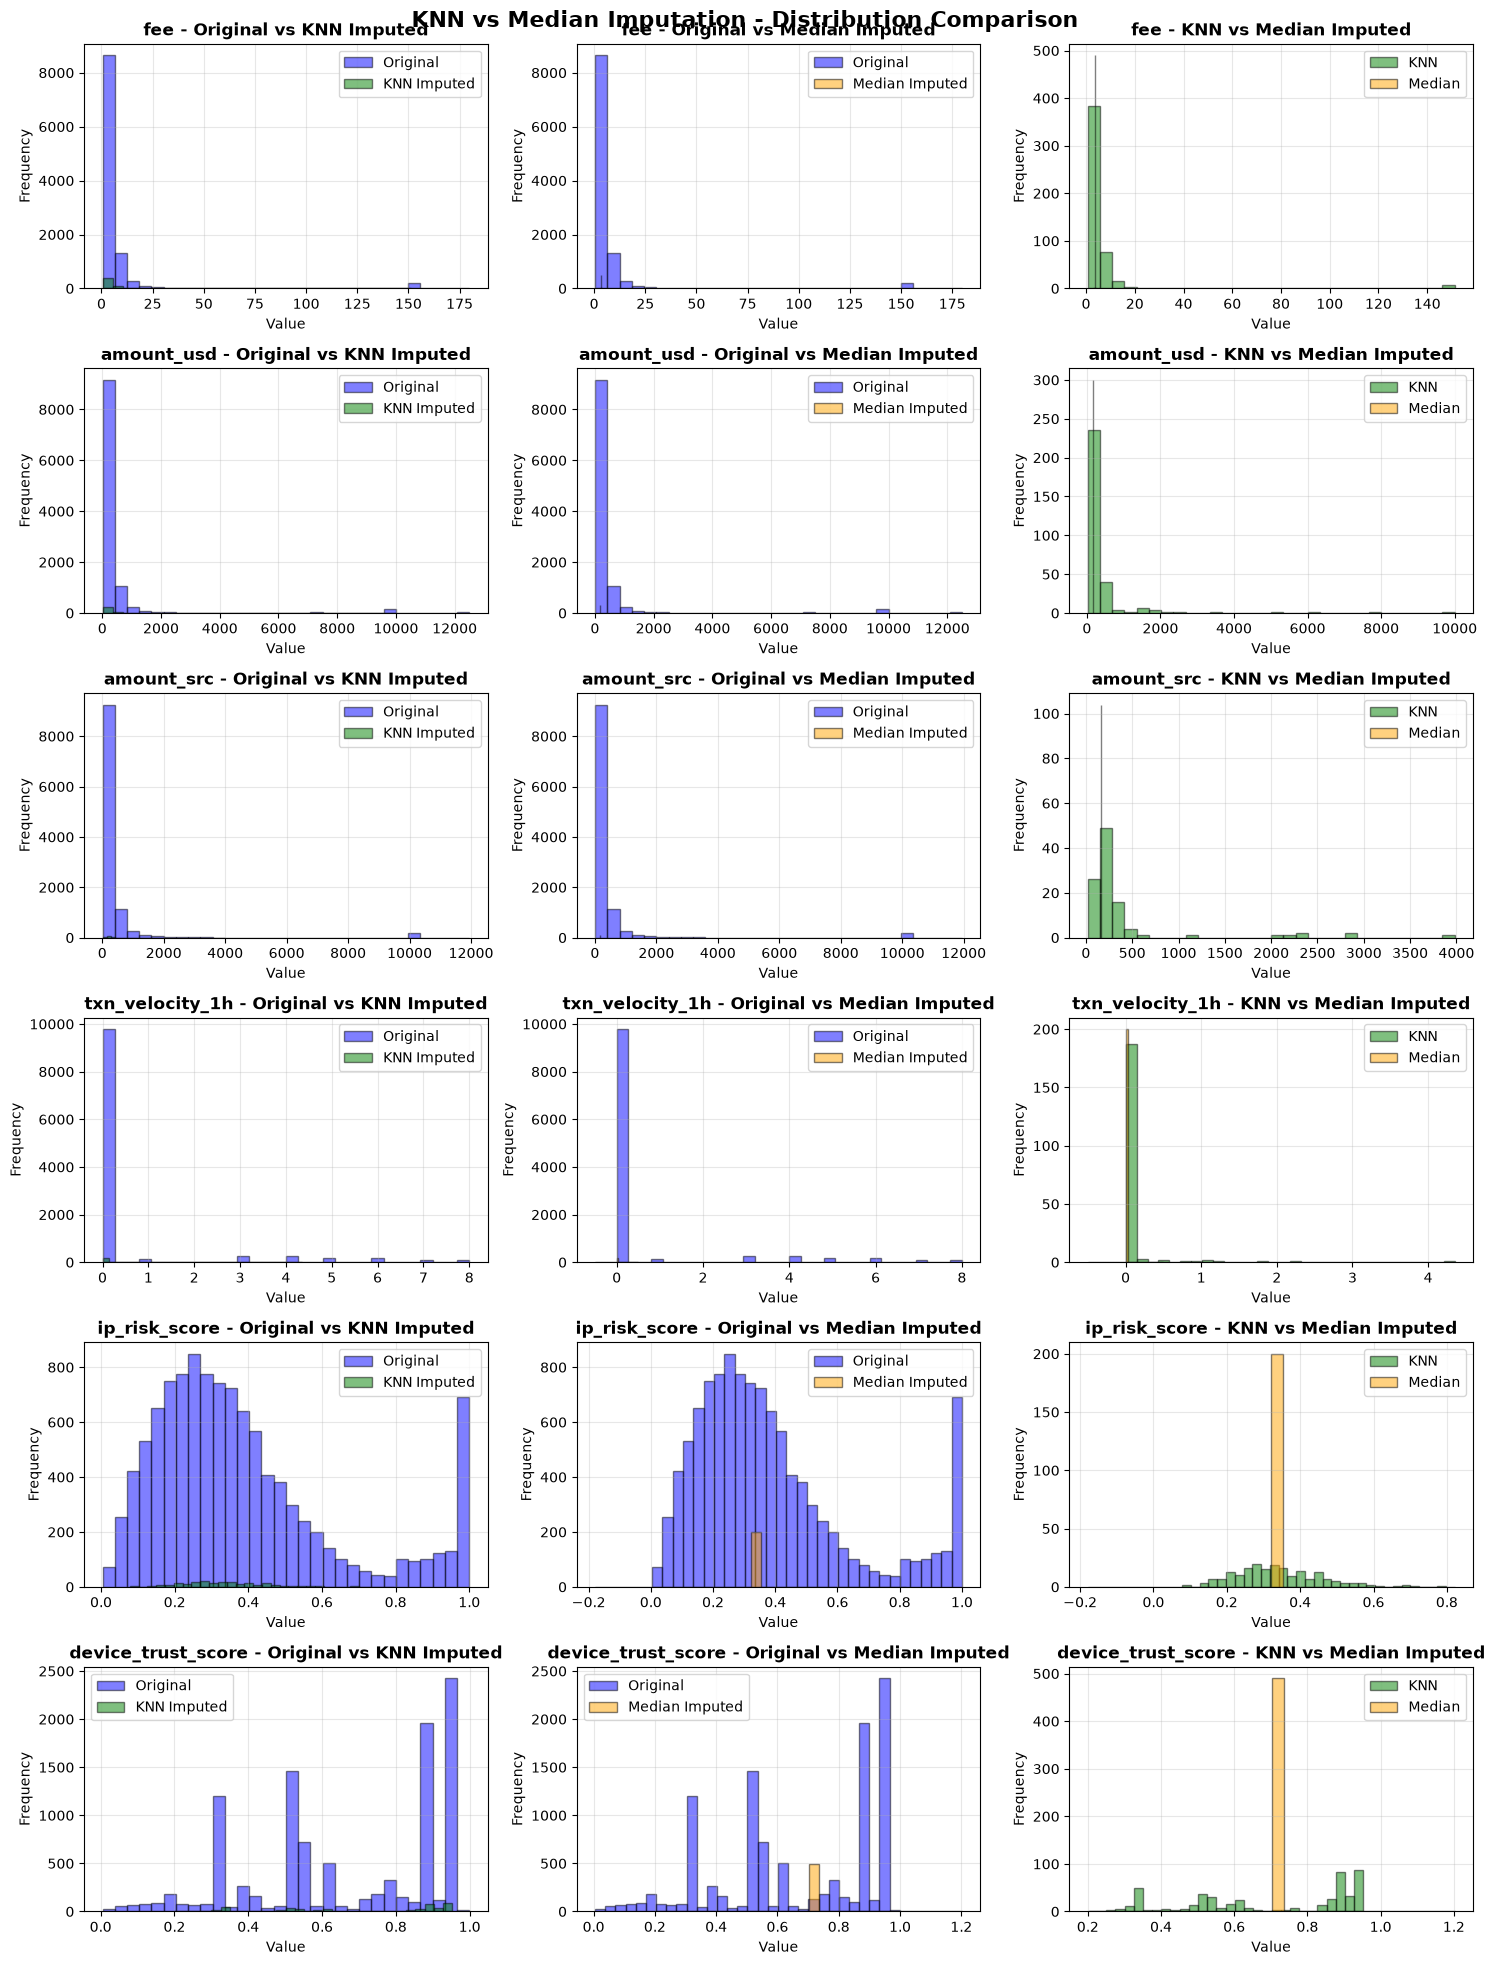


📊 Visualization Key Insights:
--------------------------------------------------------------------------------
• LEFT: Original vs KNN - Shows how KNN preserves original distribution shape
• MIDDLE: Original vs Median - Shows median's impact on distribution
• RIGHT: KNN vs Median - Direct comparison of imputation methods


In [17]:
fig, axes = plt.subplots(6, 3, figsize=(15, 20))
fig.suptitle('KNN vs Median Imputation - Distribution Comparison', fontsize=16, fontweight='bold')

cols_to_plot = ['fee', 'amount_usd', 'amount_src', 'txn_velocity_1h', 'ip_risk_score', 'device_trust_score']

for idx, col in enumerate(cols_to_plot):
    if col in original_missing_mask:
        missing_mask = original_missing_mask[col]
        
        if missing_mask.sum() > 0:
            original_data = data_imputation.loc[~missing_mask, col]
            knn_imputed = data_knn.loc[missing_mask, col]
            median_imputed = data_median.loc[missing_mask, col]
            
            ax1 = axes[idx, 0]
            ax1.hist(original_data, bins=30, alpha=0.5, label='Original', color='blue', edgecolor='black')
            ax1.hist(knn_imputed, bins=30, alpha=0.5, label='KNN Imputed', color='green', edgecolor='black')
            ax1.set_title(f'{col} - Original vs KNN Imputed', fontweight='bold')
            ax1.set_xlabel('Value')
            ax1.set_ylabel('Frequency')
            ax1.legend()
            ax1.grid(alpha=0.3)
            
            ax2 = axes[idx, 1]
            ax2.hist(original_data, bins=30, alpha=0.5, label='Original', color='blue', edgecolor='black')
            ax2.hist(median_imputed, bins=30, alpha=0.5, label='Median Imputed', color='orange', edgecolor='black')
            ax2.set_title(f'{col} - Original vs Median Imputed', fontweight='bold')
            ax2.set_xlabel('Value')
            ax2.set_ylabel('Frequency')
            ax2.legend()
            ax2.grid(alpha=0.3)
            
            ax3 = axes[idx, 2]
            ax3.hist(knn_imputed, bins=30, alpha=0.5, label='KNN', color='green', edgecolor='black')
            ax3.hist(median_imputed, bins=30, alpha=0.5, label='Median', color='orange', edgecolor='black')
            ax3.set_title(f'{col} - KNN vs Median Imputed', fontweight='bold')
            ax3.set_xlabel('Value')
            ax3.set_ylabel('Frequency')
            ax3.legend()
            ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/knn_vs_median_comparison.png', dpi=100, bbox_inches='tight')
print('✓ Distribution comparison plot saved to: ../visualizations/knn_vs_median_comparison.png')
plt.show()

print('\n📊 Visualization Key Insights:')
print('-' * 80)
print('• LEFT: Original vs KNN - Shows how KNN preserves original distribution shape')
print('• MIDDLE: Original vs Median - Shows median\'s impact on distribution')
print('• RIGHT: KNN vs Median - Direct comparison of imputation methods')

#### Step 5: Use KNN for final imputation

In [18]:
print('\n' + '='*80)
print('DECISION: USING KNN IMPUTATION FOR FINAL DATASET')
print('='*80 + '\n')

print('Rationale for KNN Imputation:')
print('-' * 80)
print('✓ Preserves relationships: Uses k nearest neighbors (similar transactions)')
print('✓ Maintains variance: Better approximates original data distribution')
print('✓ Context-aware: Considers multiple features instead of single statistic')
print('✓ Fraud detection: Captures patterns specific to customer profiles')
print('✓ Non-biased: Doesn\'t artificially skew data like median imputation\n')

data = data_knn.copy()

# Backfill missing timestamps without using fillna(method=...) to avoid pandas compatibility issues
data['timestamp'] = data['timestamp'].bfill()
data['kyc_tier'] = data['kyc_tier'].fillna(data['kyc_tier'].mode()[0] if len(data['kyc_tier'].mode()) > 0 else 'standard')
data['ip_address'] = data['ip_address'].fillna('unknown')
data['ip_country'] = data['ip_country'].fillna('unknown')

print('✓ KNN imputation applied to final dataset')
print(f'  Rows: {len(data):,}')
print(f'  Total missing values: {data.isnull().sum().sum()}')
print(f'\nImputation Summary:')
for col in ['fee', 'amount_usd', 'amount_src', 'txn_velocity_1h', 'ip_risk_score', 'device_trust_score']:
    if col in original_missing_mask:
        print(f'  {col}: {original_missing_mask[col].sum()} values imputed')

print(f'\n✓ Final verification:')
for col in ['fee', 'amount_usd', 'amount_src', 'txn_velocity_1h', 'ip_risk_score', 'device_trust_score', 'timestamp', 'kyc_tier']:
    if col in data.columns:
        print(f'  {col}: {data[col].isna().sum()} missing values')


DECISION: USING KNN IMPUTATION FOR FINAL DATASET

Rationale for KNN Imputation:
--------------------------------------------------------------------------------
✓ Preserves relationships: Uses k nearest neighbors (similar transactions)
✓ Maintains variance: Better approximates original data distribution
✓ Context-aware: Considers multiple features instead of single statistic
✓ Fraud detection: Captures patterns specific to customer profiles
✓ Non-biased: Doesn't artificially skew data like median imputation

✓ KNN imputation applied to final dataset
  Rows: 11,200
  Total missing values: 0

Imputation Summary:
  fee: 490 values imputed
  amount_usd: 300 values imputed
  amount_src: 104 values imputed
  txn_velocity_1h: 200 values imputed
  ip_risk_score: 200 values imputed
  device_trust_score: 490 values imputed

✓ Final verification:
  fee: 0 missing values
  amount_usd: 0 missing values
  amount_src: 0 missing values
  txn_velocity_1h: 0 missing values
  ip_risk_score: 0 missing va

## STEP 8: SEPARATE IDENTIFIER COLUMNS

Now that the data is cleaned and missing values are handled, we **subset the identifier columns into their own DataFrame** before feature engineering and (later) encoding.

### 8.1 EXPLORE: confirm which columns are identifiers

We classify each column into one of three roles:
- **Identifiers** — labels we keep aside (`transaction_id`, `customer_id`, `device_id`, `ip_address`)
- **Target** — the thing we predict (`is_fraud`) — never an input feature
- **Features** — everything else, the descriptive columns the model learns from

We deliberately **keep `customer_id` and `device_id` accessible** because the very next step (feature engineering) needs them to compute *behavioural* features by grouping. We separate them only so they never accidentally flow into scaling or one-hot encoding.

In [19]:
print('\n🔍 IDENTIFIER SEPARATION — EXPLORATION\n')

# Define the three roles explicitly. This is a design decision you document.
identifier_cols = [c for c in ['transaction_id', 'customer_id', 'device_id', 'ip_address']
                   if c in data.columns]
target_col = 'is_fraud'
feature_cols = [c for c in data.columns
                if c not in identifier_cols and c != target_col]

print(f'IDENTIFIER columns ({len(identifier_cols)}): {identifier_cols}')
print(f'TARGET column: {target_col}')
print(f'FEATURE columns ({len(feature_cols)}): {feature_cols}\n')

# Show WHY each identifier qualifies (high cardinality)
print('Justification — uniqueness of each identifier:')
for c in identifier_cols:
    print(f'  {c:18}: {data[c].nunique():,} unique / {len(data):,} rows '
          f'({data[c].nunique()/len(data)*100:.1f}%)')


🔍 IDENTIFIER SEPARATION — EXPLORATION

IDENTIFIER columns (4): ['transaction_id', 'customer_id', 'device_id', 'ip_address']
TARGET column: is_fraud
FEATURE columns (21): ['timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'new_device', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk']

Justification — uniqueness of each identifier:
  transaction_id    : 11,200 unique / 11,200 rows (100.0%)
  customer_id       : 1,315 unique / 11,200 rows (11.7%)
  device_id         : 2,113 unique / 11,200 rows (18.9%)
  ip_address        : 10,901 unique / 11,200 rows (97.3%)


In [20]:
# FIX: subset identifiers into their own DataFrame.
# We RESET the index on the main data first so the two DataFrames stay aligned
# row-for-row. This shared index is how we recombine them safely later.
data = data.reset_index(drop=True)

# identifiers_df holds the labels (kept aside, NOT fed to the model)
identifiers_df = data[identifier_cols].copy()

# We keep `data` containing features + identifiers FOR NOW, because feature
# engineering (Step 9) still needs customer_id / device_id to group by.
# After engineering, only the derived behaviour features remain as inputs.

print('✓ Identifiers subset into `identifiers_df`')
print(f'  identifiers_df shape: {identifiers_df.shape}')
print(f'  identifiers_df columns: {list(identifiers_df.columns)}')
print(f'\n  Main `data` still has {data.shape[1]} columns (incl. identifiers,')
print(f'  which Step 9 needs for grouping). The raw IDs will be dropped before encoding.')
print(f'\n  Both share a clean 0..N-1 index, so we can recombine by position:')
print(f'  data index aligned with identifiers_df index: '
      f'{(data.index == identifiers_df.index).all()}')

✓ Identifiers subset into `identifiers_df`
  identifiers_df shape: (11200, 4)
  identifiers_df columns: ['transaction_id', 'customer_id', 'device_id', 'ip_address']

  Main `data` still has 26 columns (incl. identifiers,
  which Step 9 needs for grouping). The raw IDs will be dropped before encoding.

  Both share a clean 0..N-1 index, so we can recombine by position:
  data index aligned with identifiers_df index: True


## STEP 9: FEATURE ENGINEERING & VALIDATION

### 📚 TEACHING NOTE — Turning identifiers into *behaviour* features

This is the payoff for keeping the identifiers around. We cannot give the model a raw `customer_id`, but we *can* ask useful questions by **grouping rows that share the same ID**:

- *"How many transactions has this customer made in total?"* → `customer_total_transactions`
- *"How many distinct devices has this customer used?"* → `customer_device_count`

`groupby('customer_id')` gathers all rows for each customer, we compute a number, then `.map()` writes that number back onto every one of that customer's rows. The result is a **descriptive feature** (a count that generalises) derived from an **identifier** (a label that does not). The raw ID has done its job and can now be dropped before modelling.

In [21]:
print('\n🔍 FEATURE ENGINEERING\n')

data['currency_pair'] = data['source_currency'] + '_' + data['dest_currency']
unique_pairs = data['currency_pair'].nunique()
print(f'✓ Created currency_pair feature: {unique_pairs} unique pairs')
print(f'  Examples: {data["currency_pair"].unique()[:5].tolist()}')

data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['day_of_month'] = data['timestamp'].dt.day
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)
print(f'✓ Created temporal features: hour, day_of_week, day_of_month, is_weekend')

print(f'\n✓ VALIDATING EXISTING FEATURES:')
print(f'  ip_risk_score range: {data["ip_risk_score"].min():.3f} - {data["ip_risk_score"].max():.3f}')
print(f'  device_trust_score range: {data["device_trust_score"].min():.3f} - {data["device_trust_score"].max():.3f}')
print(f'  corridor_risk range: {data["corridor_risk"].min():.3f} - {data["corridor_risk"].max():.3f}')
print(f'  risk_score_internal range: {data["risk_score_internal"].min():.3f} - {data["risk_score_internal"].max():.3f}')

print(f'\n✓ Boolean columns validation:')
print(f'  new_device unique values: {data["new_device"].unique()}')
print(f'  location_mismatch unique values: {data["location_mismatch"].unique()}')

print(f'\n✓ Count validation:')
print(f'  chargeback_history_count: Min={data["chargeback_history_count"].min()}, Max={data["chargeback_history_count"].max()}')
print(f'  account_age_days: Min={data["account_age_days"].min()}, Max={data["account_age_days"].max()}')

# ── Behaviour features derived FROM identifiers (the reason we kept IDs) ──
# Count transactions per customer, then map back onto each row.
customer_txn_count = data.groupby('customer_id').size()
data['customer_total_transactions'] = data['customer_id'].map(customer_txn_count)
print(f"\n✓ customer_total_transactions created from customer_id "
      f"(range {data['customer_total_transactions'].min()}–{data['customer_total_transactions'].max()})")

# Count distinct devices per customer
if 'device_id' in data.columns:
    customer_device_count = data.groupby('customer_id')['device_id'].nunique()
    data['customer_device_count'] = data['customer_id'].map(customer_device_count)
    print(f"✓ customer_device_count created from customer_id + device_id "
          f"(range {data['customer_device_count'].min()}–{data['customer_device_count'].max()})")

print("\n📌 The raw IDs (customer_id, device_id, ...) have now been turned into")
print("   model-ready behaviour features. The IDs themselves stay in identifiers_df")
print("   and will NOT be used as model inputs.")


🔍 FEATURE ENGINEERING

✓ Created currency_pair feature: 27 unique pairs
  Examples: ['USD_CAD', 'CAD_MXN', 'USD_CNY', 'USD_EUR', 'USD_INR']
✓ Created temporal features: hour, day_of_week, day_of_month, is_weekend

✓ VALIDATING EXISTING FEATURES:
  ip_risk_score range: 0.004 - 1.000
  device_trust_score range: 0.005 - 0.999
  corridor_risk range: 0.000 - 0.250
  risk_score_internal range: 0.000 - 0.900

✓ Boolean columns validation:
  new_device unique values: [False  True]
  location_mismatch unique values: [False  True]

✓ Count validation:
  chargeback_history_count: Min=0.0, Max=2.0
  account_age_days: Min=1.0, Max=1095.0

✓ customer_total_transactions created from customer_id (range 1–1483)
✓ customer_device_count created from customer_id + device_id (range 1–143)

📌 The raw IDs (customer_id, device_id, ...) have now been turned into
   model-ready behaviour features. The IDs themselves stay in identifiers_df
   and will NOT be used as model inputs.


## STEP 10: CLASS IMBALANCE ANALYSIS

In [22]:
print('\n🔍 CLASS IMBALANCE ANALYSIS\n')

fraud_dist = data['is_fraud'].value_counts()
fraud_pct = data['is_fraud'].value_counts(normalize=True) * 100

print('Fraud distribution:')
print(f'  Legitimate: {fraud_dist[0]:,} ({fraud_pct[0]:.2f}%)')
print(f'  Fraudulent: {fraud_dist[1]:,} ({fraud_pct[1]:.2f}%)')
print(f'  Imbalance ratio: {fraud_dist[0] / fraud_dist[1]:.1f}:1')

print(f'\n📊 Fraud rate by feature:')
print(f'\nBy new_device:')
print(data.groupby('new_device')['is_fraud'].agg(['sum', 'count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={0: 'fraud_rate'}))

print(f'\nBy location_mismatch:')
print(data.groupby('location_mismatch')['is_fraud'].agg(['sum', 'count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={0: 'fraud_rate'}))

print(f'\nBy channel:')
print(data.groupby('channel')['is_fraud'].agg(['sum', 'count', lambda x: f"{x.mean()*100:.2f}%"]).rename(columns={0: 'fraud_rate'}))

print(f'\n⚠️  Imbalance mitigation strategy:')
print(f'  - Use SMOTE or class weighting during model training')
print(f'  - Implement stratified train-test-validation splits')
print(f'  - Monitor precision, recall, and F1-score (not just accuracy)')


🔍 CLASS IMBALANCE ANALYSIS

Fraud distribution:
  Legitimate: 10,205 (91.12%)
  Fraudulent: 995 (8.88%)
  Imbalance ratio: 10.3:1

📊 Fraud rate by feature:

By new_device:
              sum  count <lambda_0>
new_device                         
False       484.0   9864      4.91%
True        511.0   1336     38.25%

By location_mismatch:
                     sum  count <lambda_0>
location_mismatch                         
False              338.0   9375      3.61%
True               657.0   1825     36.00%

By channel:
           sum  count <lambda_0>
channel                         
atm       81.0   1002      8.08%
mobile   299.0   6395      4.68%
unknown    1.0     37      2.70%
web      614.0   3766     16.30%

⚠️  Imbalance mitigation strategy:
  - Use SMOTE or class weighting during model training
  - Implement stratified train-test-validation splits
  - Monitor precision, recall, and F1-score (not just accuracy)


## STEP 11: FINAL VALIDATION & DATA QUALITY REPORT

In [23]:
print('\n' + '='*80)
print('DATA QUALITY REPORT - BEFORE vs AFTER')
print('='*80 + '\n')

final_rows = len(data)
final_cols = len(data.columns)
final_duplicates = data.duplicated().sum()
final_missing = data.isnull().sum().sum()
final_fraud_rate = data['is_fraud'].mean()

comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Duplicate Rows', 'Total Missing Values', 'Fraud Rate (%)'],
    'Before': [f'{baseline_rows:,}', f'{baseline_cols}', f'{baseline_duplicates}', f'{baseline_missing:,}', f'{8.75}'],
    'After': [f'{final_rows:,}', f'{final_cols}', f'{final_duplicates}', f'{final_missing:,}', f'{final_fraud_rate*100:.2f}%'],
    'Change': [
        f'{final_rows - baseline_rows:,} ({(final_rows/baseline_rows - 1)*100:.1f}%)',
        f'{final_cols - baseline_cols}',
        f'{final_duplicates - baseline_duplicates}',
        f'{final_missing - baseline_missing:,}',
        f'Maintained',
    ]
})

print(comparison.to_string(index=False))

print('\n' + '='*80)
print('DATA QUALITY CHECKS')
print('='*80 + '\n')

checks = {
    'No missing values in critical columns': data[['transaction_id', 'customer_id', 'timestamp', 'is_fraud']].isnull().sum().sum() == 0,
    'No duplicates': data.duplicated().sum() == 0,
    'No negative amounts': (data['amount_usd'] >= 0).all() and (data['amount_src'] >= 0).all(),
    'No negative fees': (data['fee'] >= 0).all(),
    'Valid exchange rates': (data['exchange_rate_src_to_dest'] > 0).all(),
    'Valid currencies': all(data['source_currency'].isin({'USD', 'CAD', 'GBP'})) and all(data['dest_currency'].isin({'USD', 'CAD', 'GBP', 'MXN', 'CNY', 'EUR', 'INR', 'PHP', 'NGN'})),
    'Valid risk scores': (data[['ip_risk_score', 'device_trust_score']].min() >= 0).all() and (data[['ip_risk_score', 'device_trust_score']].max() <= 1).all()
}

for check_name, result in checks.items():
    status = '✓ PASS' if result else '✗ FAIL'
    print(f'{status}: {check_name}')

print('\n' + '='*80)
print('READY FOR MODELING')
print('='*80)
print(f'Dataset is clean and ready for ML model training!')
print(f'Final dataset shape: {data.shape}')


DATA QUALITY REPORT - BEFORE vs AFTER

              Metric Before  After       Change
          Total Rows 11,400 11,200 -200 (-1.8%)
       Total Columns     26     33            7
      Duplicate Rows    200      0         -200
Total Missing Values  1,830      0       -1,830
      Fraud Rate (%)   8.75  8.88%   Maintained

DATA QUALITY CHECKS

✓ PASS: No missing values in critical columns
✓ PASS: No duplicates
✓ PASS: No negative amounts
✓ PASS: No negative fees
✓ PASS: Valid exchange rates
✓ PASS: Valid currencies
✓ PASS: Valid risk scores

READY FOR MODELING
Dataset is clean and ready for ML model training!
Final dataset shape: (11200, 33)


## STEP 12: SAVE CLEANED DATASET

In [24]:
# Save the cleaned dataset (features + identifiers + target together, so EDA can
# still group by IDs). EDA will perform the FINAL separation before encoding.
output_path = '../data/nova_pay_cleaned.csv'
data.to_csv(output_path, index=False)
print(f'\n✓ Cleaned dataset saved to: {output_path}')

# Also save the identifiers on their own, for reference / auditing / joining back
# predictions to real transactions later.
identifiers_df.to_csv('../data/nova_pay_identifiers.csv', index=False)
print(f'✓ Identifier columns saved separately to: ../data/nova_pay_identifiers.csv')
print(f'  identifiers_df shape: {identifiers_df.shape}')
print(f'✓ Shape: {data.shape}')
print(f'✓ Columns: {list(data.columns)}')

print('\n' + '='*80)
print('DATA DICTIONARY - CLEANED DATASET')
print('='*80 + '\n')

data_dict = pd.DataFrame({
    'Column': data.columns,
    'Data Type': data.dtypes.astype(str),
    'Non-Null Count': len(data) - data.isnull().sum(),
    'Unique Values': [data[col].nunique() for col in data.columns],
    'Sample Value': [str(data[col].iloc[0])[:50] for col in data.columns]
})

print(data_dict.to_string(index=False))

print('\n✓ Data cleaning pipeline completed successfully!')
print('✓ Ready for EDA and feature engineering')


✓ Cleaned dataset saved to: ../data/nova_pay_cleaned.csv
✓ Identifier columns saved separately to: ../data/nova_pay_identifiers.csv
  identifiers_df shape: (11200, 4)
✓ Shape: (11200, 33)
✓ Columns: ['transaction_id', 'customer_id', 'timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id', 'new_device', 'ip_address', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'currency_pair', 'hour', 'day_of_week', 'day_of_month', 'is_weekend', 'customer_total_transactions', 'customer_device_count']

DATA DICTIONARY - CLEANED DATASET

                     Column           Data Type  Non-Null Count  Unique Values                         Sample Value
             transaction_id                 str           11200          11200 fee